In [2]:
pip install pillow

Note: you may need to restart the kernel to use updated packages.


In [3]:
from PIL import Image

# open image
img = Image.open("airplane.png")

# convert to grayscale
img = img.convert("L")

# resize to 32x32 just in case
img = img.resize((32, 32))

# save mem file
with open("airplane.mem", "w") as f:
    for y in range(32):
        for x in range(32):
            pixel = img.getpixel((x, y))
            f.write(f"{pixel:02x}\n")

print("image.mem generated successfully")

image.mem generated successfully


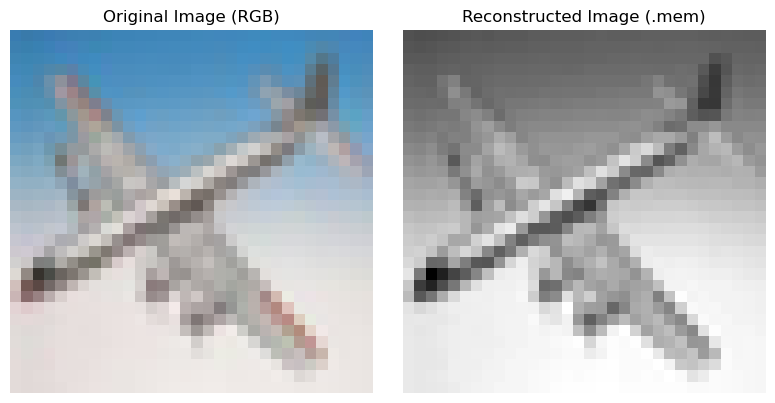

In [2]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load original image
orig = Image.open("airplane.png")

# Load mem file
data = np.loadtxt("airplane.mem", dtype=str)
data = np.array([int(x, 16) for x in data])
img_mem = data.reshape((32, 32))

# Plot side by side
plt.figure(figsize=(8,4))

# Original image
plt.subplot(1,2,1)
plt.imshow(orig)
plt.title("Original Image (RGB)")
plt.axis('off')

# Reconstructed from .mem
plt.subplot(1,2,2)
plt.imshow(img_mem, cmap='gray')
plt.title("Reconstructed Image (.mem)")
plt.axis('off')

plt.tight_layout()
plt.show()

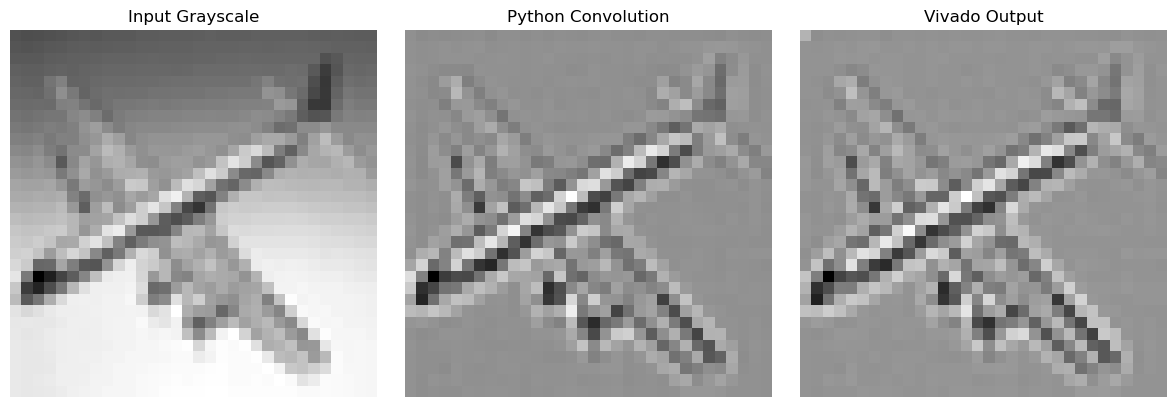

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open("airplane.png").convert("L")
img = img.resize((32, 32))
img_np = np.array(img, dtype=np.int32)

kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.int32)

# edge replication padding
padded = np.pad(img_np, pad_width=1, mode='edge')

python_out = np.zeros((32,32), dtype=np.int32)

for r in range(32):
    for c in range(32):
        window = padded[r:r+3, c:c+3]
        python_out[r, c] = np.sum(window * kernel)

verilog_out = np.loadtxt("output_airplane.txt").reshape((32,32))

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_np, cmap="gray")
plt.title("Input Grayscale")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(python_out, cmap="gray")
plt.title("Python Convolution")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(verilog_out, cmap="gray")
plt.title("Vivado Output")
plt.axis("off")

plt.tight_layout()
plt.show()

## For Phase 2 of the CNN Project

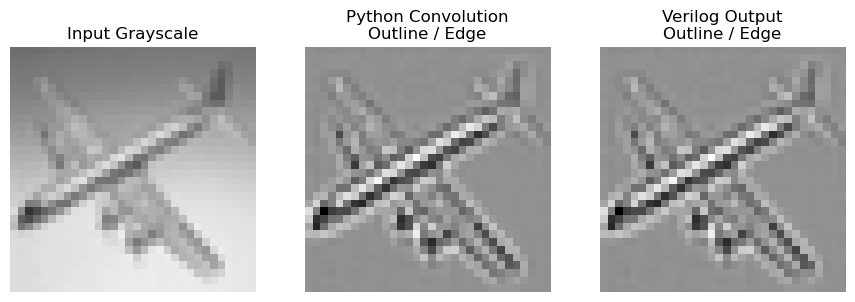

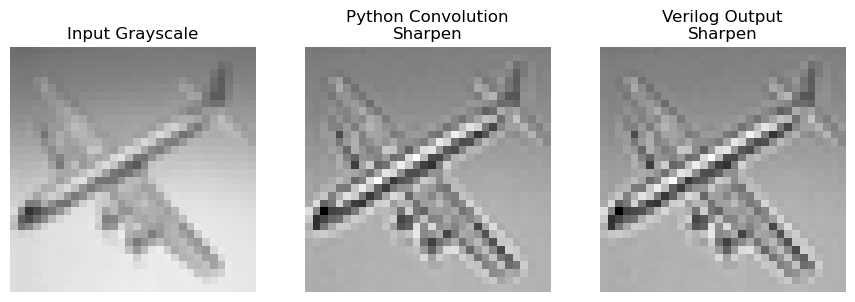

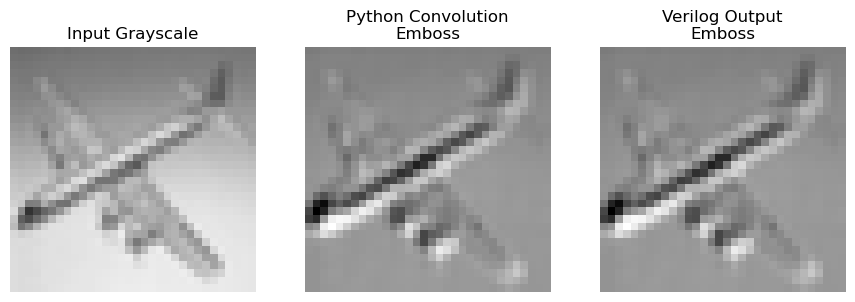

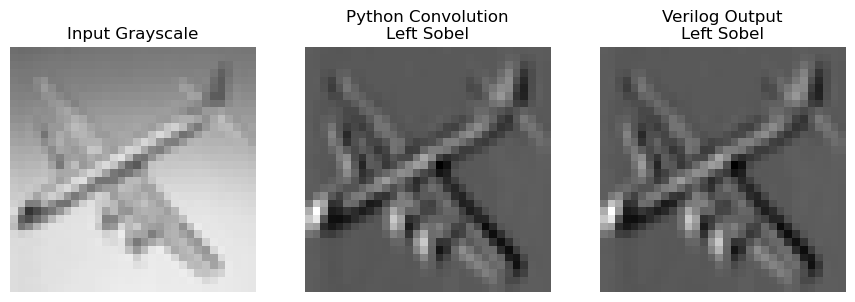

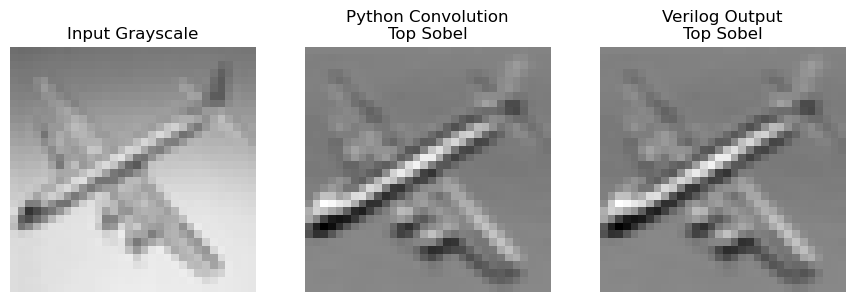

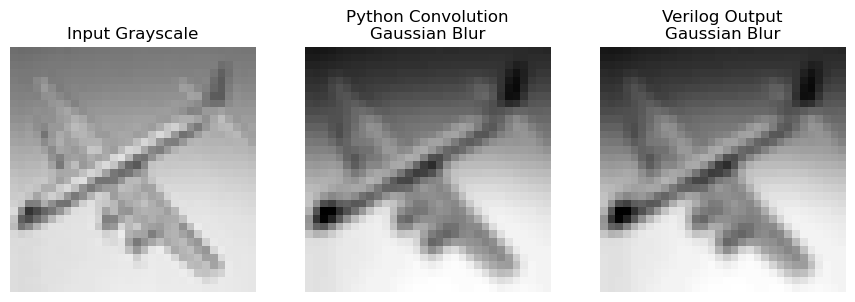

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Load airplane.mem 
def load_mem(filename, H=32, W=32):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                data.append(int(line, 16))
    return np.array(data, dtype=np.int32).reshape(H, W)

img = load_mem("airplane.mem", 32, 32)

# KERNEL
kernels = {
    "gaussian": np.array([
        [1, 2, 1],
        [2, 4, 2],
        [1, 2, 1]
    ], dtype=np.int32),      #this will be divided to 16 later 

    "emboss": np.array([
        [-2, -1,  0],
        [-1,  1,  1],
        [ 0,  1,  2]
    ], dtype=np.int32),

    "sobel_left": np.array([
        [ 1,  0, -1],
        [ 2,  0, -2],
        [ 1,  0, -1]
    ], dtype=np.int32),

    "sharpen": np.array([
        [ 0, -1,  0],
        [-1,  5, -1],
        [ 0, -1,  0]
    ], dtype=np.int32),

    "edge": np.array([
        [-1, -1, -1],
        [-1,  8, -1],
        [-1, -1, -1]
    ], dtype=np.int32),

    "sobel_top": np.array([
        [ 1,  2,  1],
        [ 0,  0,  0],
        [-1, -2, -1]
    ], dtype=np.int32)
}

# Edge replication, same idea as controller row/col clamping
def get_pixel_edge_replicate(img, r, c):
    H, W = img.shape
    r = max(0, min(r, H - 1))
    c = max(0, min(c, W - 1))
    return img[r, c]

# Python convolution - for reference
def convolve_like_verilog(img, kernel, scale_shift=0):
    H, W = img.shape
    out = np.zeros((H, W), dtype=np.int32)

    for out_r in range(H):
        for out_c in range(W):
            acc = 0

            # k_idx mapping:
            # 0 1 2
            # 3 4 5
            # 6 7 8
            k_idx = 0
            for kr in [-1, 0, 1]:
                for kc in [-1, 0, 1]:
                    pixel = get_pixel_edge_replicate(img, out_r + kr, out_c + kc)
                    coeff = kernel[kr + 1, kc + 1]
                    acc += pixel * coeff
                    k_idx += 1

            # Since Gaussian uses scale_shift = 4, meaning divide by 16 
            if scale_shift > 0:
                acc = acc >> scale_shift

            out[out_r, out_c] = acc

    return out

# Generate Python convolution results
python_results = {
    "edge": convolve_like_verilog(img, kernels["edge"], scale_shift=0),
    "sharpen": convolve_like_verilog(img, kernels["sharpen"], scale_shift=0),
    "emboss": convolve_like_verilog(img, kernels["emboss"], scale_shift=0),
    "sobel_left": convolve_like_verilog(img, kernels["sobel_left"], scale_shift=0),
    "sobel_top": convolve_like_verilog(img, kernels["sobel_top"], scale_shift=0),
    "gaussian": convolve_like_verilog(img, kernels["gaussian"], scale_shift=4)
}

# Verilog output text files
verilog_files = {
    "edge": "output_kernel0_edge.txt",
    "sharpen": "output_kernel1_sharpen.txt",
    "emboss": "output_kernel2_emboss.txt",
    "sobel_left": "output_kernel3_leftsobel.txt",
    "sobel_top": "output_kernel4_topsobel.txt",
    "gaussian": "output_kernel5_gaussian_scaled.txt"
}

verilog_results = {}

for name, filename in verilog_files.items():
    data = np.loadtxt(filename, dtype=np.int32)
    verilog_results[name] = data.reshape(32, 32)

    
# Compare Python and Verilog results
for name in python_results.keys():
    py = python_results[name]
    vg = verilog_results[name]

  #  match = np.array_equal(py, vg)
  #  max_diff = np.max(np.abs(py - vg))

   # print(f"{name:12s} | Match: {match} | Max Difference: {max_diff}")

def normalize_for_display(x):
    x = x.astype(np.float32)
    x_min = x.min()
    x_max = x.max()

    if x_max == x_min:
        return np.zeros_like(x)

    return (x - x_min) / (x_max - x_min)

# 9. Show input grayscale, Python convolution, and Verilog output
display_names = {
    "edge": "Outline / Edge",
    "sharpen": "Sharpen",
    "emboss": "Emboss",
    "sobel_left": "Left Sobel",
    "sobel_top": "Top Sobel",
    "gaussian": "Gaussian Blur"
}

for name in ["edge", "sharpen", "emboss", "sobel_left", "sobel_top", "gaussian"]:
    plt.figure(figsize=(9, 3))

    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    plt.title("Input Grayscale")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(normalize_for_display(python_results[name]), cmap="gray")
    plt.title(f"Python Convolution\n{display_names[name]}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(normalize_for_display(verilog_results[name]), cmap="gray")
    plt.title(f"Verilog Output\n{display_names[name]}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


## For Phase 3 

Input image loaded successfully.
Image shape: (32, 32)
Python reference outputs generated.
edge      : loaded 256 values from pooled_kernel0_edge.txt
sharpen   : loaded 256 values from pooled_kernel1_sharpen.txt
emboss    : loaded 256 values from pooled_kernel2_emboss.txt
leftsobel : loaded 256 values from pooled_kernel3_leftsobel.txt
topsobel  : loaded 256 values from pooled_kernel4_topsobel.txt
gaussian  : loaded 256 values from pooled_kernel5_gaussian_scaled.txt
Verilog pooled outputs loaded successfully.

PHASE 3 POOLED OUTPUT VERIFICATION
Python: convolution → ReLU → 2x2 max pooling
Verilog: pooled_kernel*.txt files from tb_node.v
edge       | Match: True | Max Difference: 0
sharpen    | Match: True | Max Difference: 0
emboss     | Match: True | Max Difference: 0
leftsobel  | Match: True | Max Difference: 0
topsobel   | Match: True | Max Difference: 0
gaussian   | Match: True | Max Difference: 0

RESULT: PASSED. All Verilog pooled outputs match Python reference.


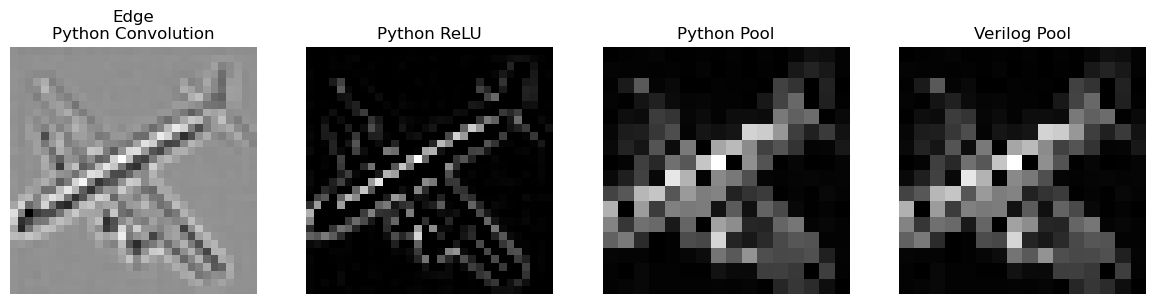

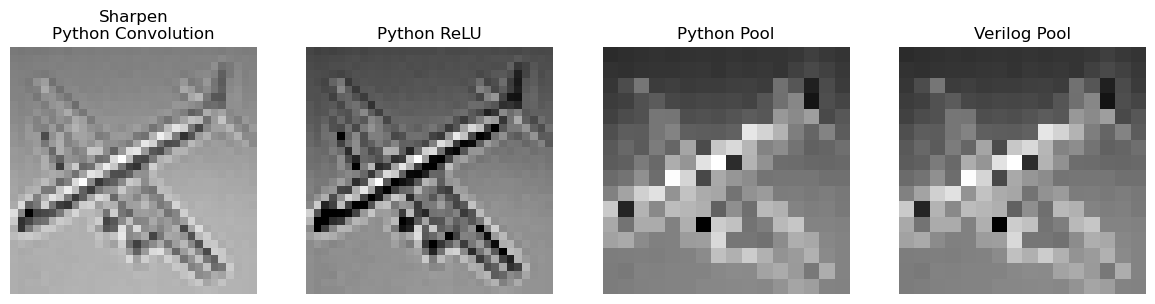

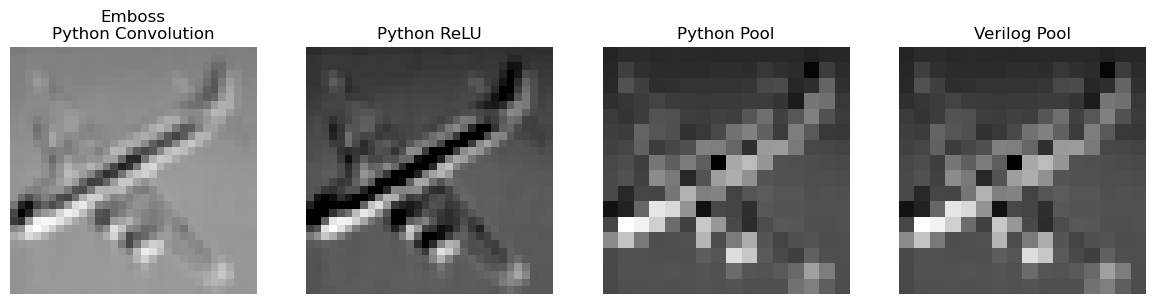

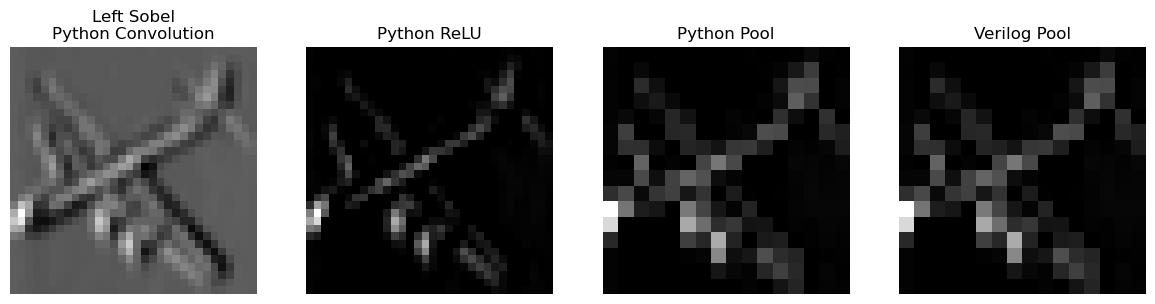

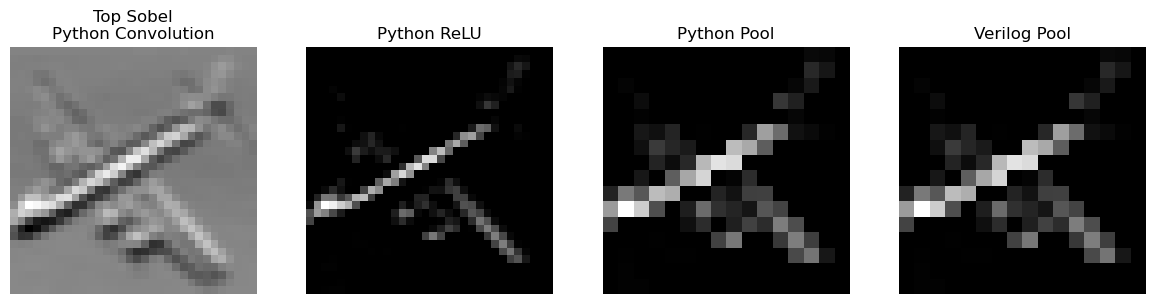

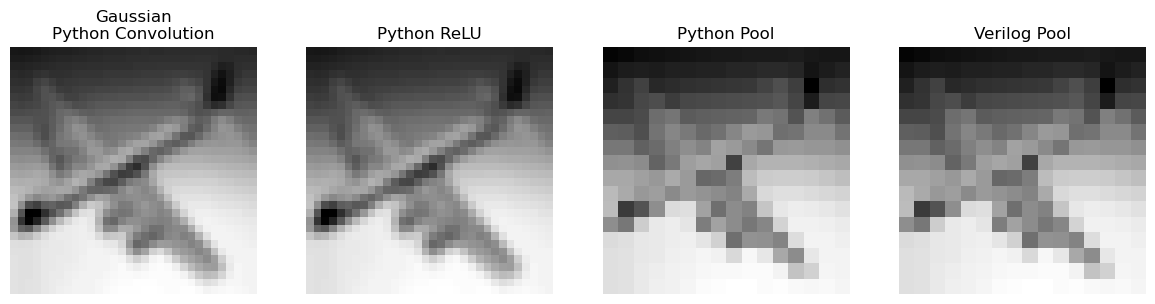

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# SETTINGS

H = 32
W = 32

MEM_FILE = "airplane.mem"

# Verilog pooled output files generated by tb_node.v
verilog_pool_files = {
    "edge": "pooled_kernel0_edge.txt",
    "sharpen": "pooled_kernel1_sharpen.txt",
    "emboss": "pooled_kernel2_emboss.txt",
    "leftsobel": "pooled_kernel3_leftsobel.txt",
    "topsobel": "pooled_kernel4_topsobel.txt",
    "gaussian": "pooled_kernel5_gaussian_scaled.txt"
}

# LOAD INPUT IMAGE FROM .mem FILE
def load_mem_image(filename, H=32, W=32):
    pixels = []

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                pixels.append(int(line, 16))

    pixels = np.array(pixels, dtype=np.int32)

    if len(pixels) != H * W:
        raise ValueError(f"Expected {H*W} pixels, but found {len(pixels)} pixels.")

    return pixels.reshape(H, W)

img = load_mem_image(MEM_FILE, H, W)

print("Input image loaded successfully.")
print("Image shape:", img.shape)

# KERNEL DEFINITIONS

kernels = {
    "edge": np.array([
        [-1, -1, -1],
        [-1,  8, -1],
        [-1, -1, -1]
    ], dtype=np.int32),

    "sharpen": np.array([
        [ 0, -1,  0],
        [-1,  5, -1],
        [ 0, -1,  0]
    ], dtype=np.int32),

    "emboss": np.array([
        [-2, -1,  0],
        [-1,  1,  1],
        [ 0,  1,  2]
    ], dtype=np.int32),

    "leftsobel": np.array([
        [ 1,  0, -1],
        [ 2,  0, -2],
        [ 1,  0, -1]
    ], dtype=np.int32),

    "topsobel": np.array([
        [ 1,  2,  1],
        [ 0,  0,  0],
        [-1, -2, -1]
    ], dtype=np.int32),

    "gaussian": np.array([
        [1, 2, 1],
        [2, 4, 2],
        [1, 2, 1]
    ], dtype=np.int32)
}

# This implements the right shift by 4 for gaussian as you need to divide it by 16 
scale_shift = {
    "edge": 0,
    "sharpen": 0,
    "emboss": 0,
    "leftsobel": 0,
    "topsobel": 0,
    "gaussian": 4
}

# PYTHON REFERENCE MODEL
def get_pixel_edge_replicate(img, r, c):

    H, W = img.shape

    if r < 0:
        r = 0
    elif r >= H:
        r = H - 1

    if c < 0:
        c = 0
    elif c >= W:
        c = W - 1

    return img[r, c]


def convolve_3x3(img, kernel, shift=0): #edge replication 

    H, W = img.shape
    out = np.zeros((H, W), dtype=np.int32)

    for r in range(H):
        for c in range(W):
            acc = 0

            for kr in range(3):
                for kc in range(3):
                    rr = r + kr - 1
                    cc = c + kc - 1

                    pixel = get_pixel_edge_replicate(img, rr, cc)
                    coeff = kernel[kr, kc]

                    acc += pixel * coeff

            # Used for Gaussian scaled output
            if shift > 0:
                acc = acc >> shift

            out[r, c] = acc

    return out


def relu(x): #negative values = 0; positive values = unchanged;

    return np.maximum(0, x)


def max_pool_2x2_stride2(x): #stride 2 so 32x32 becomes 16x16

    H, W = x.shape
    pooled = np.zeros((H // 2, W // 2), dtype=np.int32)

    for r in range(0, H, 2):
        for c in range(0, W, 2):
            window = x[r:r+2, c:c+2]
            pooled[r//2, c//2] = np.max(window)

    return pooled


# GENERATE EXPECTED PYTHON OUTPUTS

python_conv = {}
python_relu = {}
python_pool = {}

for name in kernels:
    python_conv[name] = convolve_3x3(
        img,
        kernels[name],
        shift=scale_shift[name]
    )

    python_relu[name] = relu(python_conv[name])
    python_pool[name] = max_pool_2x2_stride2(python_relu[name])

print("Python reference outputs generated.")

# LOAD VERILOG POOLED OUTPUTS (came from Testbench result)

verilog_pool = {}

for name, filename in verilog_pool_files.items():
    data = np.loadtxt(filename, dtype=np.int32)

    print(f"{name:10s}: loaded {len(data)} values from {filename}")

  #  if len(data) != 256:
  #      raise ValueError(
  #          f"{filename} should contain 256 pooled values, but found {len(data)}."
  #      )

    verilog_pool[name] = data.reshape(16, 16)

print("Verilog pooled outputs loaded successfully.")

# COMPARING PYTHON VS VERILOG

print("\n============================================================")
print("PHASE 3 POOLED OUTPUT VERIFICATION")
print("Python: convolution → ReLU → 2x2 max pooling")
print("Verilog: pooled_kernel*.txt files from tb_node.v")
print("============================================================")

all_passed = True

for name in kernels:
    expected = python_pool[name]
    actual = verilog_pool[name]

    match = np.array_equal(expected, actual)
    max_diff = np.max(np.abs(expected - actual))

    print(f"{name:10s} | Match: {match} | Max Difference: {max_diff}") #for checking if there is a difference between Python and Verilog

    if not match:
        all_passed = False

        mismatches = np.argwhere(expected != actual)

        print(f"  Number of mismatches: {len(mismatches)}")
        print("  First 10 mismatches:")

        for r, c in mismatches[:10]:
            print(
                f"    row={r}, col={c}, "
                f"Python={expected[r,c]}, Verilog={actual[r,c]}"
            )

print("\n============================================================")

if all_passed:
    print("RESULT: PASSED. All Verilog pooled outputs match Python reference.")
else:
    print("RESULT: FAILED.")

print("============================================================")

# DISPLAY IMAGES

def normalize_for_display(x):
    x = x.astype(np.float32)
    x_min = x.min()
    x_max = x.max()

    if x_max == x_min:
        return np.zeros_like(x)

    return (x - x_min) / (x_max - x_min)


display_names = {
    "edge": "Edge",
    "sharpen": "Sharpen",
    "emboss": "Emboss",
    "leftsobel": "Left Sobel",
    "topsobel": "Top Sobel",
    "gaussian": "Gaussian"
}

for name in kernels:
    plt.figure(figsize=(12, 3))

    plt.subplot(1, 4, 1)
    plt.imshow(normalize_for_display(python_conv[name]), cmap="gray")
    plt.title(f"{display_names[name]}\nPython Convolution")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(normalize_for_display(python_relu[name]), cmap="gray")
    plt.title("Python ReLU")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(normalize_for_display(python_pool[name]), cmap="gray")
    plt.title("Python Pool")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(normalize_for_display(verilog_pool[name]), cmap="gray")
    plt.title("Verilog Pool")
    plt.axis("off")

    plt.tight_layout()
    plt.show()